**Question 4.1**

In [1]:
x = [1,2,3,10]
y = [10, 20, 30, 40]
new_list = []
for i in zip(x,y):
    new_list.append(sum(i))
new_list

[11, 22, 33, 50]

In [2]:
newer_list = [sum(i) for i in zip(x,y)]
newer_list

[11, 22, 33, 50]

In [3]:
even_newer_list = list(map(sum,zip(x,y)))
even_newer_list

[11, 22, 33, 50]

**Question 4.3**

In [6]:
import numpy as np
game_on = True
def game():
    """One round of rock-paper-scissors"""
    
    signs = ['R','P','S']
    sign = input('Type R for rock, P for paper or S for scissors:').upper()   # gets the sign and converts it to a capital letter (if someone hits lowercase)
    if not(sign in signs):                                                    # checks if the given sign is valid : quits if not
        return "Error"
    
    generated = signs[np.random.randint(0,2)]                                 # if the user input is valid, the code continues to run : generating the machine's sign
    print(f"Machine says: {generated}")
    if sign == 'S' and generated == 'R':                                      # machine's rock beats user's scissors
        return "Machine"
    elif signs.index(sign) == signs.index(generated)-1:                       # R loses to P, P loses to S : Machine wins 
        return "Machine"
    elif signs.index(sign) == signs.index(generated)+1:                       # P wins to R, S wins to P : User wins
        return "User"
    elif signs.index(sign) == signs.index(generated):                         # if the two signs are equal : draw
        return "Draw"

while game_on:
    print(game(),"won this round.")                                           # result of a round
    next_ = input("Do you want to continue? [y/n]").upper()                   # asks for next round
    if next_ == 'N':
        game_on = False                                                       # stops loop upon request
    elif next_ == 'Y':
        pass
    else:
        while next_ != 'Y' or next_ != 'N':
            next_ = input("Input cannot be comprehended, please type 'y' or 'n'!").upper()
print("Thank you for playing!")

Type R for rock, P for paper or S for scissors: s


Machine says: P
User won this round.


Do you want to continue? [y/n] y


Y


Type R for rock, P for paper or S for scissors: s


Machine says: P
User won this round.


Do you want to continue? [y/n] n


N


**Question 4.4**

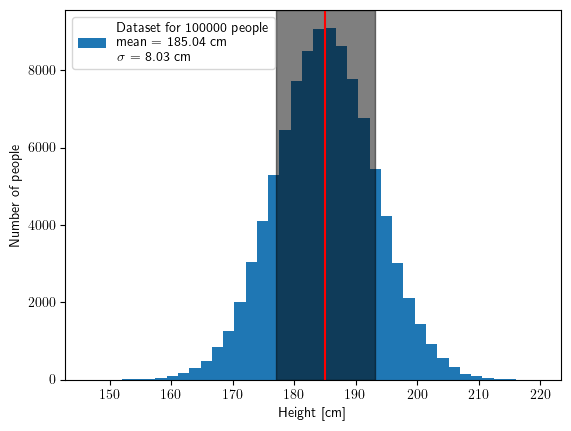

The mean of the dataset is 185.04350566050013, which differs by 0.043505660500130716 from the original parameter.
The standard deviation of the dataset is 8.028833944013625, which differs by 0.028833944013625157 from the original parameter.


Input a height (h): 199


A random point in the dataset has a 95.99% chanche for being less than h.
A random height has a 62.77% chanche for being less than 1 sigma far from the mean.


In [60]:
import matplotlib.pyplot as plt
from scipy import stats, sparse
data = np.random.normal(185,8,100000)

plt.rc("text",usetex=True)
plt.hist(data, bins = 40, label=f"Dataset for 100000 people \nmean = {np.mean(data):.2f} cm \n$\sigma$ = {np.std(data):.2f} cm")
plt.xlabel("Height [cm]")
plt.ylabel("Number of people")
plt.legend()
plt.axvline(x = np.mean(data), color = 'red')
plt.axvspan(np.mean(data)-np.std(data), np.mean(data)+np.std(data), color = 'black', alpha = 0.5)
plt.show()

print(f"The mean of the dataset is {np.mean(data)}, which differs by {np.mean(data)-185} from the original parameter.")
print(f"The standard deviation of the dataset is {np.std(data)}, which differs by {np.std(data)-8} from the original parameter.")

h = float(input("Input a height (h):"))
print(f"A random point in the dataset has a {stats.norm.cdf(h, 185, 8)*100:.2f}% chanche for being less than h.")
print(f"A random height has a {(stats.norm.cdf(np.mean(data)+np.std(data),185,9)-stats.norm.cdf(np.mean(data)-np.std(data),185,9))*100:.2f}% chanche for being less than 1 sigma far from the mean.")

**Question 4.6**

In [37]:
from numpy import *
fun = input("Input a function:")
xmin = float(input("Input the lower bound:"))
xmax = float(input("Input the upper bound:"))
n = 100000
x = linspace(xmin,xmax,n)
y = eval(fun)

integral = sum(y)*(xmax-xmin)/n
integral

Input a function: x
Input the lower bound: 0
Input the upper bound: 1


0.5000000000000001

**Question 4.12**

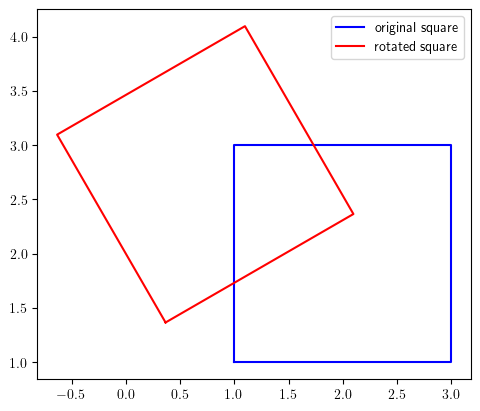

In [88]:
angle = 30
angle = radians(angle)
rotor = cos(angle)+1j*sin(angle)

x = np.array([1,3,3,1,1])
y = np.array([1,1,3,3,1])
r = x + y*1j

x1 = (rotor*r).real
y1 = (rotor*r).imag

plt.plot(x,y,color='blue', label = 'original square')
plt.plot(x1,y1,color='red', label = 'rotated square')
plt.legend()
plt.gca().set_aspect('equal', 'box')
plt.show()

**Question 4.14**

In [127]:
import numpy as np
def funcfilter(func,seq):
    seq = np.asarray(seq)
    x = []
    for i in seq:
        if i > 0:
            x.append(i)
    return func(np.array(x))

sq = np.array([-100, -10, 0, 10, 100])
result = funcfilter(np.log10, sq)
print("Result log10:", result)

Result log10: [1. 2.]


**Question 4.16**

In [146]:
from astropy.cosmology import Planck18
import scipy
import math

H0 = Planck18.H0.value/(3.086e+19)
Om0 = Planck18.Om0
Ode0 = Planck18.Ode0

z = 2

def F(x):
    f = H0*math.sqrt(Om0*(1+x)**3+Ode0)*(1+x)
    return 1/f

integral = scipy.integrate.quad(F,0,z)[0]
in_Gy = integral/(3600*24*365*10**9)

print(f"For z = {z}, the lookback time is {in_Gy:.2f} Gyr.")

For z = 2, the lookback time is 10.53 Gyr.


**Question 4.21**

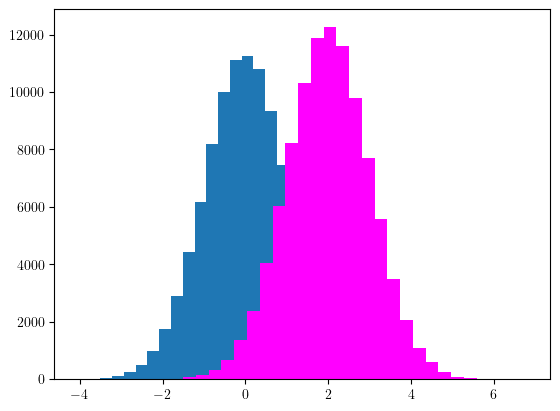

In [149]:
set1 = np.random.normal(0,1,100000)
set2 = np.random.normal(2,1,100000)

plt.hist(set1, bins = 30, label=f"Dataset for 100000 points \nmean = 0 \n$\sigma$ = 1")
plt.hist(set2, bins = 30, label=f"Dataset for 100000 points \nmean = 2 \n$\sigma$ = 1", color='magenta')

plt.show()